# Laboratorio 6: proyecciones, topología y comunidades

Este notebook desarrolla los ejercicios 5, 6 y 7 a partir de la red bipartita autor–video. El análisis conserva todos los nodos con participación observada y utiliza identificadores estables para evitar confundir nombres visibles con entidades únicas.

## Criterios de interpretación

- Una conexión autor–autor significa **coparticipación en al menos un video**, no amistad, conversación directa ni acuerdo.
- Una conexión video–video significa **audiencia compartida dentro de los comentarios disponibles**.
- Los pesos de las proyecciones cuentan vecinos compartidos distintos; no suman `reply_count` ni la cantidad total de comentarios.
- Los aislamientos y componentes describen la cobertura observada. La ausencia de una conexión no demuestra que la relación no exista fuera de la muestra.

In [1]:
from pathlib import Path
from collections import Counter
import re
import unicodedata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from IPython.display import display
from networkx.algorithms import bipartite
from networkx.algorithms.community import louvain_communities, modularity

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 90)
plt.style.use('seaborn-v0_8-whitegrid')

## Preparación de la red

Se cargan los datos procesados y las tablas de nodos y aristas. La búsqueda de rutas permite ejecutar el notebook tanto desde la carpeta del proyecto como desde `notebooks`.

In [2]:
def encontrar_raiz():
    candidatos = [Path.cwd(), Path.cwd().parent]
    for candidato in candidatos:
        if (candidato / 'data_processed' / 'youtube_comments_processed.csv').exists():
            return candidato
    raise FileNotFoundError('No se encontró la carpeta del laboratorio con los datos procesados.')

RAIZ = encontrar_raiz()
comments = pd.read_csv(RAIZ / 'data_processed' / 'youtube_comments_processed.csv')
videos = pd.read_csv(RAIZ / 'data_processed' / 'youtube_videos_processed.csv')
tabla_nodos = pd.read_csv(RAIZ / 'output' / 'tabla_nodos.csv')
tabla_aristas = pd.read_csv(RAIZ / 'output' / 'tabla_aristas.csv')

print(f'Comentarios procesados: {len(comments):,}')
print(f'Videos disponibles: {len(videos):,}')
print(f'Nodos con participación: {len(tabla_nodos):,}')
print(f'Aristas autor–video: {len(tabla_aristas):,}')

Comentarios procesados: 406
Videos disponibles: 293
Nodos con participación: 351
Aristas autor–video: 343


In [3]:
red_bipartita = nx.Graph(nombre='Red bipartita autor-video')

for fila in tabla_nodos.to_dict('records'):
    atributos = {k: v for k, v in fila.items() if k != 'node_id' and pd.notna(v)}
    atributos['bipartite'] = 0 if fila['tipo'] == 'autor' else 1
    red_bipartita.add_node(fila['node_id'], **atributos)

for fila in tabla_aristas.to_dict('records'):
    red_bipartita.add_edge(fila['source'], fila['target'], weight=int(fila['peso']))

autores = [n for n, d in red_bipartita.nodes(data=True) if d['tipo'] == 'autor']
videos_red = [n for n, d in red_bipartita.nodes(data=True) if d['tipo'] == 'video']

assert bipartite.is_bipartite(red_bipartita)
assert red_bipartita.number_of_edges() == len(tabla_aristas)
assert sum(d['weight'] for _, _, d in red_bipartita.edges(data=True)) == len(comments)
print(f'Red validada: {len(autores)} autores, {len(videos_red)} videos y {red_bipartita.number_of_edges()} relaciones únicas.')

Red validada: 332 autores, 19 videos y 343 relaciones únicas.


# 5. Proyecciones de la red

La proyección autor–autor conecta personas que comentaron en un mismo video y su peso es el número de videos compartidos. La proyección video–video conecta contenidos comentados por al menos un mismo autor y su peso es el número de autores compartidos. Los pesos originales de la red bipartita no se trasladan: publicar varios comentarios en un mismo video no crea vecinos compartidos adicionales.

In [4]:
proyeccion_autores = bipartite.weighted_projected_graph(
    red_bipartita, autores, ratio=False
)
proyeccion_videos = bipartite.weighted_projected_graph(
    red_bipartita, videos_red, ratio=False
)

def validar_peso_proyeccion(proyeccion, bipartita_original):
    return all(
        datos['weight'] == len(set(bipartita_original[u]) & set(bipartita_original[v]))
        for u, v, datos in proyeccion.edges(data=True)
    )

assert validar_peso_proyeccion(proyeccion_autores, red_bipartita)
assert validar_peso_proyeccion(proyeccion_videos, red_bipartita)

comparacion_proyecciones = pd.DataFrame({
    'red': ['Autor–autor', 'Video–video'],
    'nodos': [proyeccion_autores.number_of_nodes(), proyeccion_videos.number_of_nodes()],
    'aristas': [proyeccion_autores.number_of_edges(), proyeccion_videos.number_of_edges()],
    'peso_total': [
        sum(d['weight'] for _, _, d in proyeccion_autores.edges(data=True)),
        sum(d['weight'] for _, _, d in proyeccion_videos.edges(data=True))
    ],
    'peso_maximo': [
        max((d['weight'] for _, _, d in proyeccion_autores.edges(data=True)), default=0),
        max((d['weight'] for _, _, d in proyeccion_videos.edges(data=True)), default=0)
    ]
})
comparacion_proyecciones

,red,nodos,aristas,peso_total,peso_maximo
0,Autor–autor,332,10732,10734,2
1,Video–video,19,11,13,2


In [5]:
def aristas_destacadas(grafo, n=10):
    filas = []
    for u, v, d in sorted(grafo.edges(data=True), key=lambda x: x[2]['weight'], reverse=True)[:n]:
        filas.append({
            'nodo_1': grafo.nodes[u].get('nombre', u),
            'nodo_2': grafo.nodes[v].get('nombre', v),
            'peso': d['weight']
        })
    return pd.DataFrame(filas)

print('Pares de autores con más videos compartidos:')
display(aristas_destacadas(proyeccion_autores))
print('Pares de videos con más autores compartidos:')
display(aristas_destacadas(proyeccion_videos))

Pares de autores con más videos compartidos:


,nodo_1,nodo_2,peso
0,@hashojea7348,@Alejandro00710,2
1,@inge_vergueta,@Jel.Awesh.M,2
2,@MarcosCarillo-b1r,@pedroros6358,1
3,@MarcosCarillo-b1r,@Lyrics_GT,1
4,@MarcosCarillo-b1r,@javiercifuentesarchila6041,1
5,@MarcosCarillo-b1r,@lisss1908,1
6,@MarcosCarillo-b1r,@AnaDiaz-re9sq,1
7,@MarcosCarillo-b1r,@EdgarcalderonCalderong,1
8,@MarcosCarillo-b1r,@caminoseternos752,1
9,@MarcosCarillo-b1r,@NataliaRodriguez-rx5mr,1


Pares de videos con más autores compartidos:


,nodo_1,nodo_2,peso
0,La cooptación de Walter Mazariegos en la USAC,Qué rico come tu diputado,2
1,Internet: escoger el menos malo,Arroz con pollo a la MONOPOLIO,2
2,Capturan a presuntos delincuentes disfrazados de mujer señalados de cometer asalto,Inician los trabajos de recuperación del Puente Belice II.,1
3,Inician los trabajos de recuperación del Puente Belice II.,Conferencia de Prensa del Gobierno de Guatemala. #LaRondaGt,1
4,Conferencia de Prensa del Gobierno de Guatemala. #LaRondaGt,Qué rico come tu diputado,1
5,Caminar en una ciudad hecha para carros,Internet: escoger el menos malo,1
6,Caminar en una ciudad hecha para carros,Arroz con pollo a la MONOPOLIO,1
7,Bloqueos en Guatemala este 31 de agosto por alza en combustibles afectan rutas princip...,Qué rico come tu diputado,1
8,Capturan a ladrón que había quedado grabado mientras robaba en una parroquia de Retalh...,La cooptación de Walter Mazariegos en la USAC,1
9,La cooptación de Walter Mazariegos en la USAC,Internet: escoger el menos malo,1


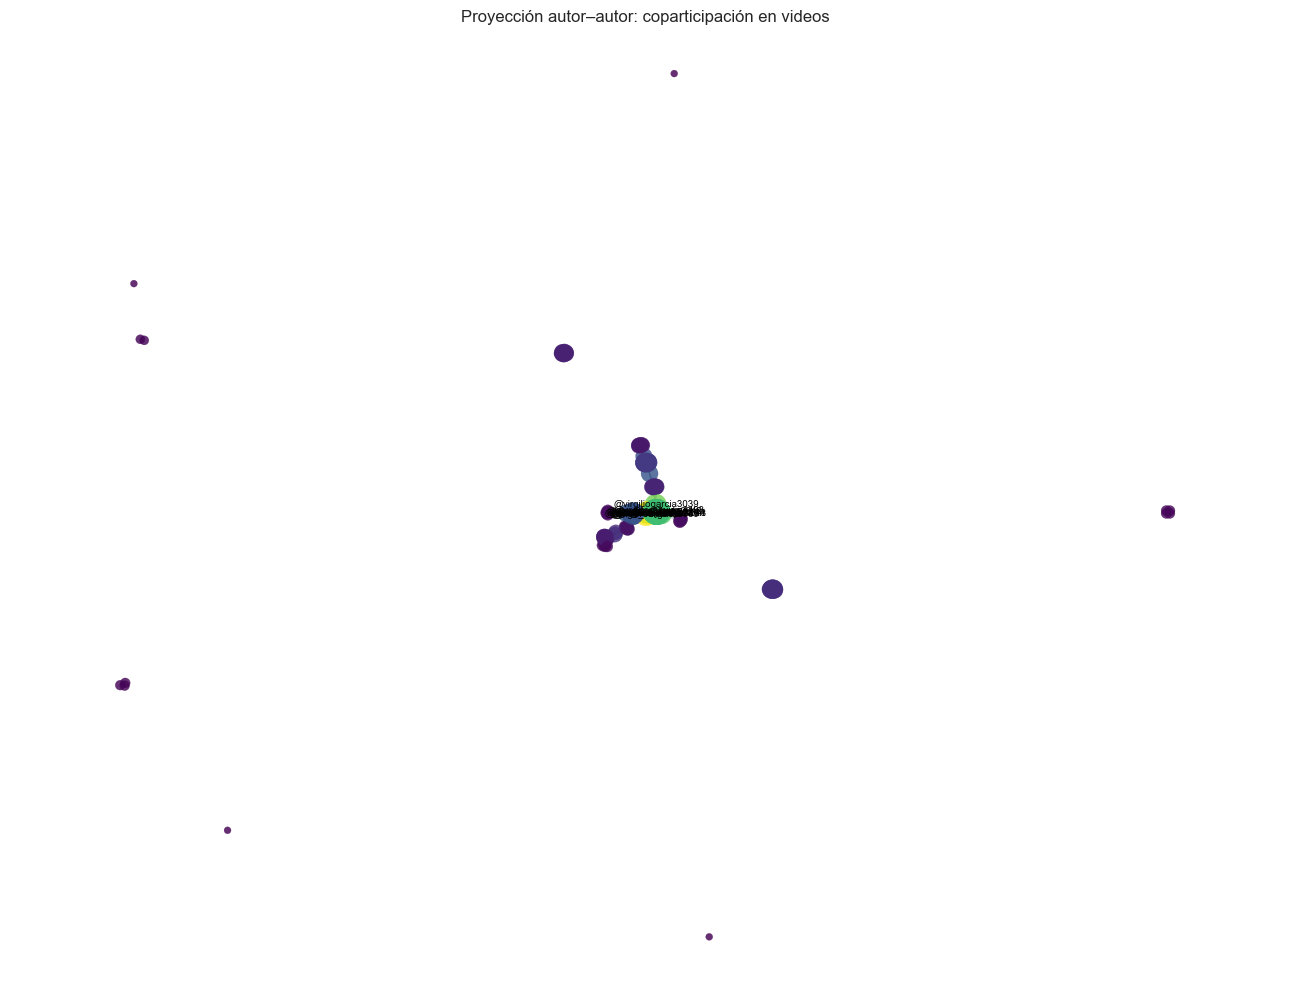

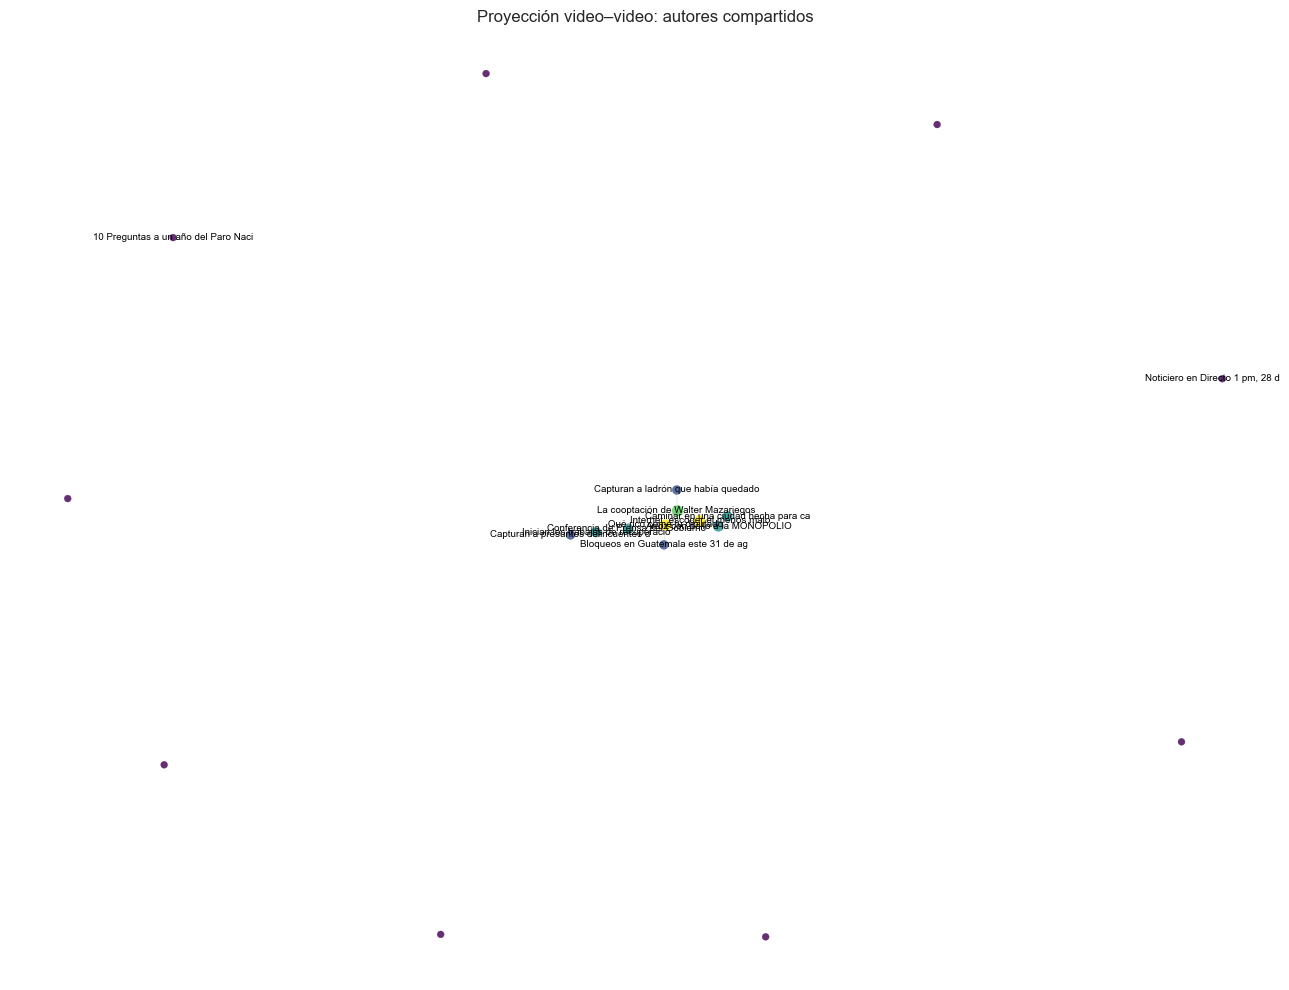

In [6]:
def dibujar_proyeccion(grafo, titulo, semilla=42, max_etiquetas=12):
    fig, ax = plt.subplots(figsize=(13, 10))
    pos = nx.spring_layout(grafo, seed=semilla, weight='weight', iterations=150)
    grados = dict(grafo.degree())
    grados_peso = dict(grafo.degree(weight='weight'))
    tamanos = [25 + 18 * np.sqrt(grados_peso[n]) for n in grafo.nodes()]
    pesos = [d['weight'] for _, _, d in grafo.edges(data=True)]
    anchos = [0.25 + 0.55 * np.log1p(p) for p in pesos]
    nx.draw_networkx_edges(grafo, pos, width=anchos, alpha=0.16, edge_color='#526777', ax=ax)
    nx.draw_networkx_nodes(grafo, pos, node_size=tamanos, node_color=list(grados.values()),
                           cmap='viridis', alpha=0.82, linewidths=0.2, ax=ax)
    candidatos = sorted(grados, key=grados.get, reverse=True)[:max_etiquetas]
    etiquetas = {n: grafo.nodes[n].get('nombre', n)[:35] for n in candidatos}
    nx.draw_networkx_labels(grafo, pos, labels=etiquetas, font_size=7, ax=ax)
    ax.set_title(titulo)
    ax.axis('off')
    plt.tight_layout()
    plt.show()

dibujar_proyeccion(proyeccion_autores, 'Proyección autor–autor: coparticipación en videos')
dibujar_proyeccion(proyeccion_videos, 'Proyección video–video: autores compartidos')

### Discusión de las proyecciones

La red autor–autor representa coincidencias de consumo participativo: una zona densa puede surgir porque muchas personas comentaron el mismo video, incluso si cada una participó una sola vez. La red video–video representa circulación de audiencias: una arista fuerte identifica contenidos que comparten varios autores. Por ello, la primera proyección es útil para estudiar agrupamientos de participantes, mientras que la segunda permite comparar contenidos y será la base de la detección de comunidades.

La proyección puede amplificar visualmente los videos muy comentados: un solo video con muchos autores genera numerosas parejas autor–autor. Los resultados deben leerse junto con la distribución de grados y los pesos, no solo con la apariencia del gráfico.

# 6. Topología y fragmentación

Se comparan tamaño, densidad, grado, componentes, aislamiento, cohesión local y transitividad. La **cohesión local promedio** se operacionaliza mediante el coeficiente de agrupamiento: mide qué tanto se conectan entre sí los vecinos de un nodo. La **transitividad** resume el cierre de tríadas a escala global. En una red bipartita no existen triángulos por construcción, por lo que su transitividad convencional es cero y se reporta también el agrupamiento bipartito.

In [7]:
def resumen_topologico(nombre, grafo, es_bipartita=False):
    n = grafo.number_of_nodes()
    m = grafo.number_of_edges()
    grados = np.array([g for _, g in grafo.degree()], dtype=float)
    componentes = sorted(nx.connected_components(grafo), key=len, reverse=True) if n else []
    if es_bipartita:
        cohesion = bipartite.average_clustering(grafo) if n else np.nan
    else:
        cohesion = nx.average_clustering(grafo) if n else np.nan
    return {
        'red': nombre,
        'nodos': n,
        'aristas': m,
        'densidad': nx.density(grafo) if n > 1 else 0,
        'grado_medio': grados.mean() if n else 0,
        'grado_mediano': np.median(grados) if n else 0,
        'grado_maximo': grados.max() if n else 0,
        'porcentaje_grado_0_o_1': 100 * np.mean(grados <= 1) if n else 0,
        'componentes': len(componentes),
        'componente_mayor': len(componentes[0]) if componentes else 0,
        'porcentaje_en_componente_mayor': 100 * len(componentes[0]) / n if componentes else 0,
        'aislados': nx.number_of_isolates(grafo),
        'cohesion_local_promedio': cohesion,
        'transitividad': nx.transitivity(grafo) if n else np.nan
    }

redes = {
    'Bipartita': red_bipartita,
    'Autor–autor': proyeccion_autores,
    'Video–video': proyeccion_videos
}
metricas = pd.DataFrame([
    resumen_topologico(nombre, grafo, es_bipartita=(nombre == 'Bipartita'))
    for nombre, grafo in redes.items()
]).set_index('red')
metricas.round(4)

,nodos,aristas,densidad,grado_medio,grado_mediano,grado_maximo,porcentaje_grado_0_o_1,componentes,componente_mayor,porcentaje_en_componente_mayor,aislados,cohesion_local_promedio,transitividad
red,,,,,,,,,,,,,
Bipartita,351,343,0.0056,1.9544,1.0,128.0,93.1624,10,286,81.4815,0,0.8920,0.0000
Autor–autor,332,10732,0.1953,64.6506,48.0,183.0,1.8072,10,276,83.1325,4,0.9720,0.9840
Video–video,19,11,0.0643,1.1579,1.0,4.0,63.1579,10,10,52.6316,9,0.1491,0.3158


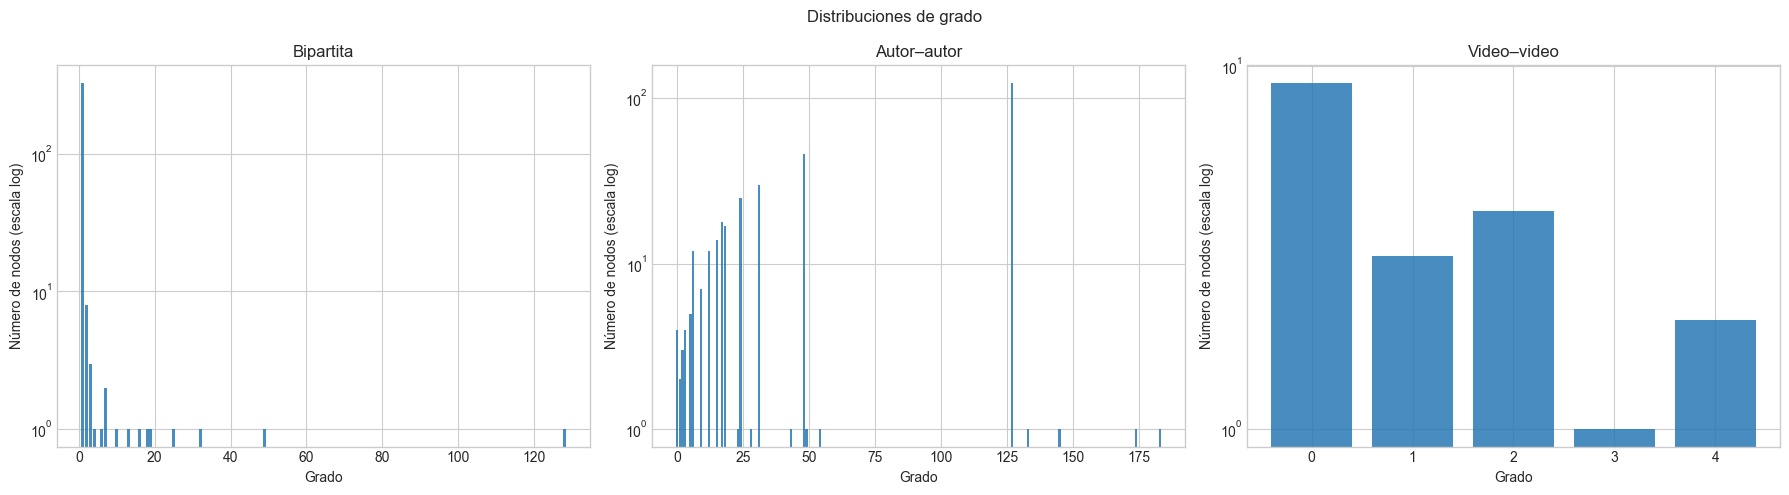

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (nombre, grafo) in zip(axes, redes.items()):
    frecuencias = Counter(dict(grafo.degree()).values())
    x = sorted(frecuencias)
    y = [frecuencias[k] for k in x]
    ax.bar(x, y, color='#2878B5', alpha=0.85)
    ax.set_yscale('log')
    ax.set_xlabel('Grado')
    ax.set_ylabel('Número de nodos (escala log)')
    ax.set_title(nombre)
plt.suptitle('Distribuciones de grado')
plt.tight_layout()
plt.show()

In [9]:
concentracion = []
for nombre, grafo in redes.items():
    grados = pd.Series(dict(grafo.degree()), dtype=float)
    total = grados.sum()
    top10 = grados.nlargest(max(1, int(np.ceil(0.10 * len(grados))))).sum()
    concentracion.append({
        'red': nombre,
        'nodos_con_grado_0_o_1': int((grados <= 1).sum()),
        'porcentaje_grado_0_o_1': 100 * (grados <= 1).mean(),
        'porcentaje_grado_en_10%_superior': 100 * top10 / total if total else 0
    })
concentracion = pd.DataFrame(concentracion).set_index('red')
concentracion.round(2)

,nodos_con_grado_0_o_1,porcentaje_grado_0_o_1,porcentaje_grado_en_10%_superior
red,,,
Bipartita,327,93.16,54.08
Autor–autor,6,1.81,20.71
Video–video,12,63.16,36.36


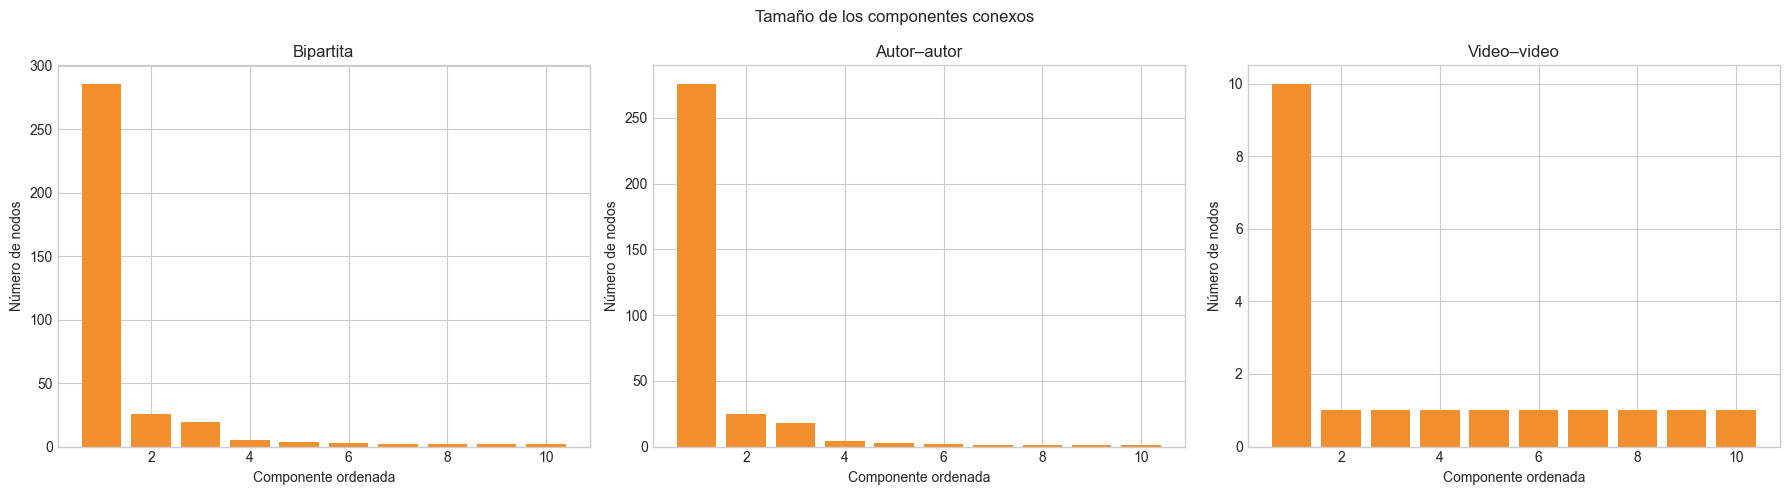

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (nombre, grafo) in zip(axes, redes.items()):
    tamanos = sorted((len(c) for c in nx.connected_components(grafo)), reverse=True)
    ax.bar(range(1, len(tamanos) + 1), tamanos, color='#F28E2B')
    ax.set_xlabel('Componente ordenada')
    ax.set_ylabel('Número de nodos')
    ax.set_title(nombre)
plt.suptitle('Tamaño de los componentes conexos')
plt.tight_layout()
plt.show()

In [11]:
def nodos_perifericos(grafo, limite=12):
    filas = []
    for nodo, grado in sorted(grafo.degree(), key=lambda x: (x[1], x[0])):
        if grado <= 1:
            filas.append({
                'id': nodo,
                'nombre': grafo.nodes[nodo].get('nombre', nodo),
                'tipo': grafo.nodes[nodo].get('tipo', ''),
                'grado': grado
            })
    return pd.DataFrame(filas).head(limite), len(filas)

for nombre, grafo in redes.items():
    muestra, total = nodos_perifericos(grafo)
    print(f'{nombre}: {total} nodos con grado 0 o 1 (se muestran hasta 12).')
    display(muestra)

Bipartita: 327 nodos con grado 0 o 1 (se muestran hasta 12).


,id,nombre,tipo,grado
0,autor::UC-HeUTT6_g-VoiWds2a4H-w,@JorgeMunoz-gd9et,autor,1
1,autor::UC-Iul5tDYH_oiAMXQH-KaaQ,@AlbertoMancilla-p9h,autor,1
2,autor::UC-QOpE7GOxlXcHZ8b7HbQKA,@mariaalexander427,autor,1
3,autor::UC-fiZBS5Gp1eCJd9ucgWnCg,@Tommii.10,autor,1
4,autor::UC-hfX8J5JPJ-dfuakzegMLA,@normaleticiaorozcojuarez2418,autor,1
5,autor::UC-jS_kA9w-OmpupXDx156Rg,@simoncreyesc7579,autor,1
6,autor::UC-pNP6RMFuLg_-x7Ah_0kEA,@almacatalan2717,autor,1
7,autor::UC094EFEmMSdwVa8NQjjYBXg,@CelestinoQuej-j7k,autor,1
8,autor::UC0HvfEWozTHbwl_iEmJNvVA,@OttoPalencia-b7r,autor,1
9,autor::UC0RpuMwkDKJYqgKHtsJRuWQ,@sabinamarinaguerra3248,autor,1


Autor–autor: 6 nodos con grado 0 o 1 (se muestran hasta 12).


,id,nombre,tipo,grado
0,autor::UC6xI_MOaxajIWpoP8BH6E_Q,@jahirdiaz5862,autor,0
1,autor::UCPLW0HE3siElqCgXfgWxMqg,@elizabethmonterroso7719,autor,0
2,autor::UCQM2tCKRRytVDRxNUfCDqQQ,@elioelias7267,autor,0
3,autor::UC_NRVt2UP88ZNTwzrZ66JSg,@aditalissethevasquezrojas8039,autor,0
4,autor::UCJxJC56BSAX-ArD0NAb9qnQ,@alfonsowilian9157,autor,1
5,autor::UCyor0Mmm0ivLX2jIdyGp84Q,@MiguelJordan-n3g,autor,1


Video–video: 12 nodos con grado 0 o 1 (se muestran hasta 12).


,id,nombre,tipo,grado
0,video::3Nfp9h5avBI,"Noticiero en Directo 1 pm, 28 de Agosto de 2026",video,0
1,video::JkpVO1hx2f8,10 Preguntas a un año del Paro Nacional,video,0
2,video::OkXlHx0hx-8,EE.UU. envía a mexicanos deportados a Guatemala antes de su regreso a México | Noticia...,video,0
3,video::TT4qJ5FXHYE,"I’x K’at: el primer equipo guatemalteco de pelota maya, conformado únicamente por muje...",video,0
4,video::UhL9y3KUl8E,SHAI WA: la vecina queer de Casa Presidencial,video,0
5,video::X_FAIef8qlE,Cruzando la ciudad a puro Transmetro,video,0
6,video::lj983NWyAQY,Plan 2032 Ciudad de Guatemala,video,0
7,video::s0eco-BofOs,¿Quiénes pagan más en Centroamérica?,video,0
8,video::zweosulrwA8,Edén por Salud: empleo inclusivo para personas con discapacidad en Antigua | Super - E...,video,0
9,video::06mFNPU0aB8,Capturan a presuntos delincuentes disfrazados de mujer señalados de cometer asalto,video,1


In [12]:
for nombre in metricas.index:
    fila = metricas.loc[nombre]
    print(
        f"{nombre}: {fila['porcentaje_en_componente_mayor']:.1f}% de los nodos está en la "
        f"componente mayor; {fila['porcentaje_grado_0_o_1']:.1f}% tiene grado 0 o 1. "
        f"La densidad es {fila['densidad']:.4f}, la cohesión local promedio "
        f"{fila['cohesion_local_promedio']:.4f} y la transitividad {fila['transitividad']:.4f}."
    )

Bipartita: 81.5% de los nodos está en la componente mayor; 93.2% tiene grado 0 o 1. La densidad es 0.0056, la cohesión local promedio 0.8920 y la transitividad 0.0000.
Autor–autor: 83.1% de los nodos está en la componente mayor; 1.8% tiene grado 0 o 1. La densidad es 0.1953, la cohesión local promedio 0.9720 y la transitividad 0.9840.
Video–video: 52.6% de los nodos está en la componente mayor; 63.2% tiene grado 0 o 1. La densidad es 0.0643, la cohesión local promedio 0.1491 y la transitividad 0.3158.


### Lectura estructural

La densidad debe compararse dentro del tipo de red: las proyecciones tienen muchas más conexiones posibles que la bipartita y un video muy concurrido puede producir un bloque autor–autor casi completo. La mediana, el porcentaje de grados 0–1 y la concentración del grado en el 10 % superior permiten decidir si la conectividad se reparte o depende de pocos nodos.

Los nodos de grado uno son periféricos porque solo enlazan con un vecino observado. En las proyecciones, un nodo aislado sí tuvo participación en la red bipartita, pero no comparte su vecino con otro nodo del mismo tipo. No equivale a falta de audiencia ni de actividad real: puede reflejar la selección de videos y la cobertura parcial de comentarios. La transitividad nula de la red bipartita es esperada porque sus aristas solo unen tipos distintos; el agrupamiento bipartito captura mejor la superposición de vecindarios en ese caso.

Los resultados muestran una estructura muy concentrada. En la red bipartita, 93.2 % de los nodos tiene grado 0 o 1 y el 10 % de mayor grado reúne 54.1 % del grado total. En cambio, la proyección autor–autor alcanza densidad 0.1953 y transitividad 0.9840: el valor alto se explica principalmente porque los autores de un mismo video forman cliques al proyectarse. La proyección video–video es mucho más fragmentada: 9 de 19 videos quedan aislados, hay 10 componentes y solo 52.6 % de sus nodos pertenece a la componente mayor. Esto indica que la circulación de autores entre videos es limitada en la muestra, aunque los pocos videos conectados sí forman algunos núcleos compartidos.

# 7. Comunidades

Se selecciona la proyección video–video porque sus comunidades se interpretan directamente como grupos de contenidos con audiencia compartida. También evita que un conjunto numeroso de autores que coincidió en un único video sea presentado como una comunidad temática sin comparar contenidos.

Se aplica Louvain con resolución 1 y semilla fija. El algoritmo busca particiones con modularidad alta respecto de una red nula que conserva aproximadamente la estructura de grados. Los pesos se conservan: compartir varios autores aporta más a la agrupación que compartir solo uno. Louvain es heurístico y la partición puede variar entre ejecuciones o resoluciones; la semilla fija hace reproducible este resultado.

In [13]:
comunidades = louvain_communities(
    proyeccion_videos, weight='weight', resolution=1, seed=42
)
comunidades = sorted(comunidades, key=len, reverse=True)
calidad_modularidad = modularity(proyeccion_videos, comunidades, weight='weight')
comunidad_de = {nodo: i + 1 for i, comunidad in enumerate(comunidades) for nodo in comunidad}
nx.set_node_attributes(proyeccion_videos, comunidad_de, 'comunidad')

tabla_comunidades = pd.DataFrame({
    'comunidad': range(1, len(comunidades) + 1),
    'videos': [len(c) for c in comunidades],
    'porcentaje_videos': [100 * len(c) / proyeccion_videos.number_of_nodes() for c in comunidades]
})
print(f'Comunidades detectadas: {len(comunidades)}')
print(f'Modularidad ponderada: {calidad_modularidad:.4f}')
tabla_comunidades.round(2)

Comunidades detectadas: 12
Modularidad ponderada: 0.4053


,comunidad,videos,porcentaje_videos
0,1,4,21.05
1,2,3,15.79
2,3,3,15.79
3,4,1,5.26
4,5,1,5.26
5,6,1,5.26
6,7,1,5.26
7,8,1,5.26
8,9,1,5.26
9,10,1,5.26


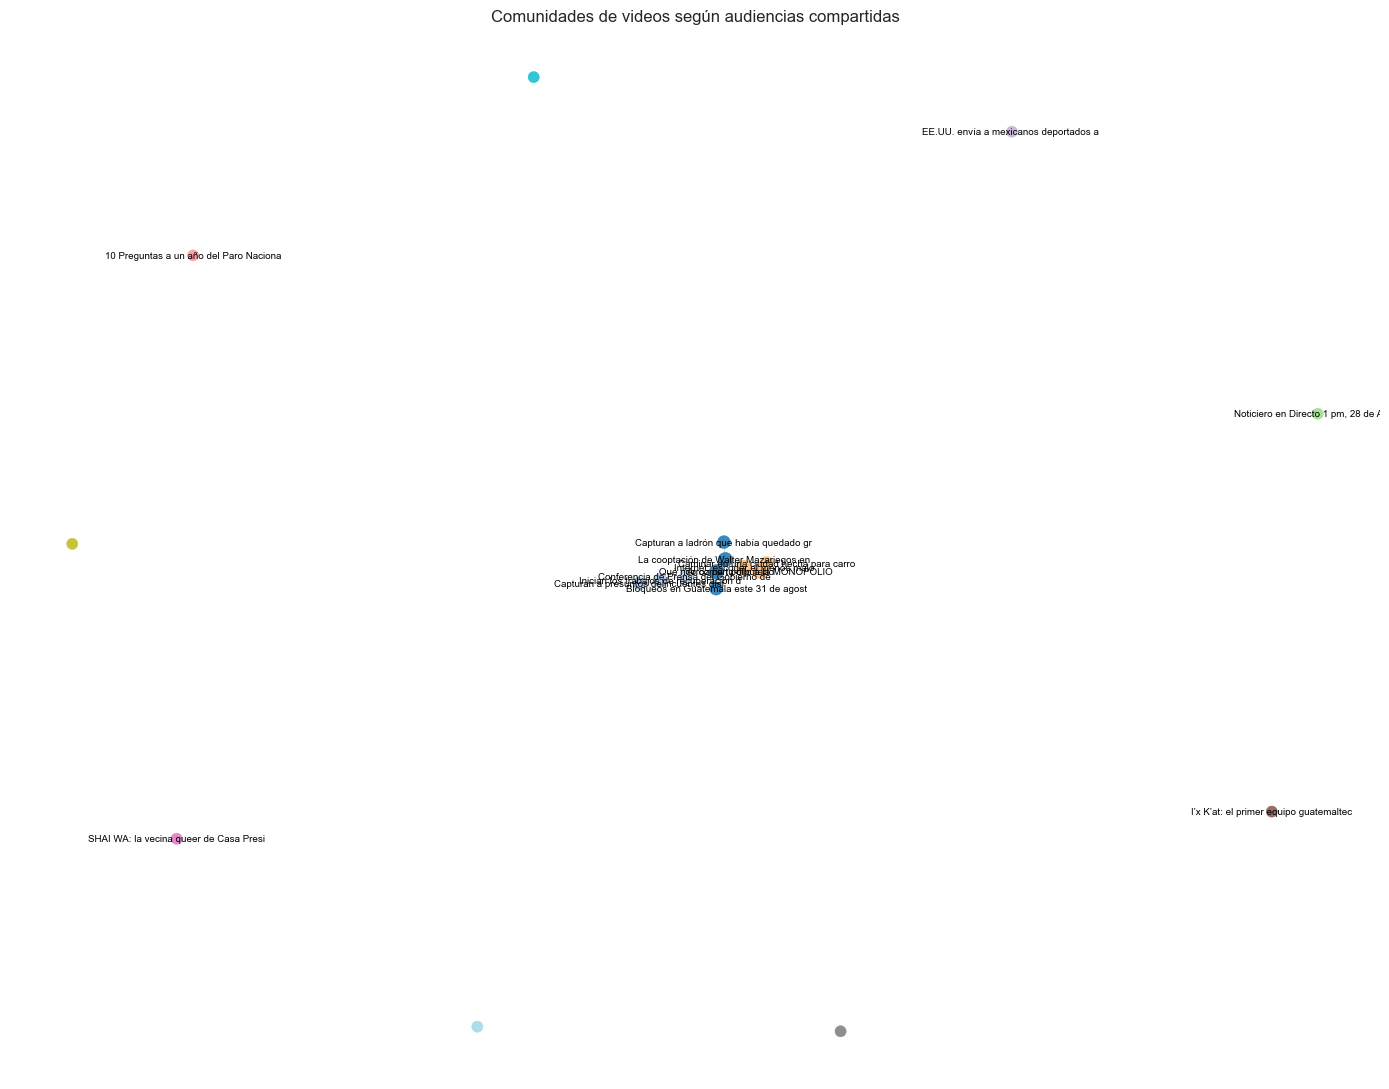

In [14]:
fig, ax = plt.subplots(figsize=(14, 11))
pos_com = nx.spring_layout(proyeccion_videos, seed=42, weight='weight', iterations=200)
colores = [comunidad_de[n] for n in proyeccion_videos.nodes()]
tamanos = [65 + 22 * np.sqrt(proyeccion_videos.degree(n, weight='weight')) for n in proyeccion_videos.nodes()]
anchos = [0.3 + 0.45 * np.log1p(d['weight']) for _, _, d in proyeccion_videos.edges(data=True)]
nx.draw_networkx_edges(proyeccion_videos, pos_com, width=anchos, alpha=0.18, ax=ax)
nx.draw_networkx_nodes(proyeccion_videos, pos_com, node_color=colores, node_size=tamanos,
                       cmap='tab20', alpha=0.88, linewidths=0.3, ax=ax)
etiquetables = sorted(proyeccion_videos, key=lambda n: proyeccion_videos.degree(n, weight='weight'), reverse=True)[:15]
etiquetas = {n: proyeccion_videos.nodes[n].get('nombre', n)[:38] for n in etiquetables}
nx.draw_networkx_labels(proyeccion_videos, pos_com, labels=etiquetas, font_size=7, ax=ax)
ax.set_title('Comunidades de videos según audiencias compartidas')
ax.axis('off')
plt.tight_layout()
plt.show()

## Caracterización de las comunidades principales

Para describir hasta tres comunidades se combinan: videos y canales, autores únicos, número de comentarios, términos frecuentes y sentimiento. El sentimiento se estima con un léxico breve en español y negación inmediata. Es una medición exploratoria y transparente: sirve para comparar la muestra, pero puede omitir ironía, modismos, emojis o palabras fuera del léxico. La clasificación formal de sentimiento puede ampliarse posteriormente con un modelo validado para español.

In [15]:
positivas = {
    'bien', 'bueno', 'buena', 'excelente', 'gracias', 'feliz', 'mejor', 'apoyo', 'apoyar',
    'amor', 'gusta', 'gustar', 'genial', 'correcto', 'correcta', 'felicidades', 'bendiciones',
    'bonito', 'bonita', 'admirable', 'esperanza', 'honesto', 'honesta', 'exito', 'alegria'
}
negativas = {
    'mal', 'malo', 'mala', 'pesimo', 'pesima', 'odio', 'corrupto', 'corrupta', 'corrupcion',
    'ladron', 'ladrona', 'mentira', 'mentiroso', 'mentirosa', 'triste', 'fracaso', 'culpa',
    'verguenza', 'asco', 'estupido', 'estupida', 'inutil', 'delito', 'criminal', 'robo',
    'violencia', 'muerto', 'muerte', 'problema', 'peligro', 'desastre', 'terrible'
}
negadores = {'no', 'nunca', 'jamas', 'ni', 'sin'}

def normalizar_token(token):
    return ''.join(c for c in unicodedata.normalize('NFD', token.lower())
                   if unicodedata.category(c) != 'Mn')

def puntuar_sentimiento(texto):
    tokens = [normalizar_token(t) for t in re.findall(r'\b[\wáéíóúüñÁÉÍÓÚÜÑ]+\b', str(texto))]
    polaridades = []
    for i, token in enumerate(tokens):
        valor = 1 if token in positivas else -1 if token in negativas else 0
        if valor and any(t in negadores for t in tokens[max(0, i - 2):i]):
            valor *= -1
        if valor:
            polaridades.append(valor)
    return sum(polaridades) / len(polaridades) if polaridades else 0.0

comments['sentimiento_score'] = comments['texto_original'].fillna('').map(puntuar_sentimiento)
comments['sentimiento'] = np.select(
    [comments['sentimiento_score'] > 0, comments['sentimiento_score'] < 0],
    ['positivo', 'negativo'], default='neutral'
)
comments['video_node_id'] = 'video::' + comments['video_id'].astype(str)
comments['comunidad'] = comments['video_node_id'].map(comunidad_de)
comments['sentimiento'].value_counts().to_frame('comentarios')

,comentarios
sentimiento,
neutral,282
positivo,83
negativo,41


In [16]:
stop_extra = {
    'que', 'qué', 'como', 'cómo', 'con', 'por', 'para', 'del', 'desde', 'hasta', 'entre',
    'los', 'las', 'una', 'uno', 'unos', 'unas', 'este', 'esta', 'estos', 'estas', 'ese',
    'esa', 'eso', 'esos', 'esas', 'aquel', 'aquella', 'sus', 'les', 'nos', 'muy', 'tan',
    'todo', 'toda', 'todos', 'todas', 'otro', 'otra', 'otros', 'otras', 'hay', 'han', 'son',
    'fue', 'era', 'sea', 'sean', 'tiene', 'tienen', 'tener', 'hacer', 'hace', 'ser', 'estar',
    'pero', 'porque', 'cuando', 'donde', 'quien', 'cual', 'cada', 'algo', 'nada', 'mismo',
    'misma', 'bien', 'aqui', 'ahi', 'tambien', 'solo', 'asi', 'mas', 'menos', 'pues', 'ya',
    'video', 'videos', 'guatemala', 'youtube', 'canal', 'dice', 'usted', 'ustedes', 'vamos',
    'puede', 'pueden', 'debe', 'sobre', 'sin', 'aun', 'año', 'años', 'vez', 'ver', 'dar',
    'eso', 'esto', 'q', 'x', 'va'
}

def terminos_frecuentes(serie, n=10):
    tokens = []
    for texto in serie.fillna(''):
        tokens.extend(
            normalizar_token(t) for t in re.findall(r'\b[\wáéíóúüñÁÉÍÓÚÜÑ]{3,}\b', str(texto))
            if normalizar_token(t) not in stop_extra
        )
    return ', '.join(f'{t} ({c})' for t, c in Counter(tokens).most_common(n))

resumen_comunidades = []
for numero, nodos in enumerate(comunidades, start=1):
    ids_video = {n.split('video::', 1)[1] for n in nodos}
    subset = comments[comments['video_id'].astype(str).isin(ids_video)]
    subgrafo = proyeccion_videos.subgraph(nodos)
    resumen_comunidades.append({
        'comunidad': numero,
        'videos': len(nodos),
        'canales': subset['channel_id'].nunique(),
        'autores_unicos': subset['author_channel_id'].nunique(),
        'comentarios': len(subset),
        'comentarios_por_video': len(subset) / len(nodos),
        'peso_interno_audiencia_compartida': sum(d['weight'] for _, _, d in subgrafo.edges(data=True)),
        'sentimiento_medio': subset['sentimiento_score'].mean(),
        'porcentaje_positivo': 100 * (subset['sentimiento'] == 'positivo').mean(),
        'porcentaje_neutral': 100 * (subset['sentimiento'] == 'neutral').mean(),
        'porcentaje_negativo': 100 * (subset['sentimiento'] == 'negativo').mean(),
        'terminos_frecuentes': terminos_frecuentes(subset['texto_limpio'])
    })
resumen_comunidades = pd.DataFrame(resumen_comunidades)
resumen_comunidades.round(2)

,comunidad,videos,canales,autores_unicos,comentarios,comentarios_por_video,peso_interno_audiencia_compartida,sentimiento_medio,porcentaje_positivo,porcentaje_neutral,porcentaje_negativo,terminos_frecuentes
0,1,4,3,187,225,56.25,4,0.04,15.11,74.22,10.67,"pueblo (54), dinero (28), diputados (28), trabajo (24), diputado (22), corruptos (21),..."
1,2,3,2,62,84,28.00,2,0.13,23.81,65.48,10.71,"presidente (27), pais (19), anos (12), arevalo (12), bernardo (9), salvador (7), estan..."
2,3,3,1,29,34,11.33,4,0.32,44.12,47.06,8.82,"excelente (10), empresas (8), internet (7), ley (7), pais (6), informacion (5), compet..."
3,4,1,1,2,2,2.00,0,-0.50,0.00,50.00,50.00,"persona (1), encargada (1), ecosistema (1), ayude (1), problema (1), recuerdos (1), de..."
4,5,1,1,3,3,3.00,0,-0.33,0.00,66.67,33.33,"cambia (1), dictadura (1), anos (1), semilla (1), bernardo (1), arevalo (1), oportunid..."
5,6,1,1,18,25,25.00,0,0.08,16.00,76.00,8.00,"pais (7), you (6), usa (4), mexico (3), bueno (2), deportan (2), personas (2), mexican..."
6,7,1,1,4,4,4.00,0,0.50,50.00,50.00,0.00,"iniciativa (3), juego (2), excelente (2), deporte (1), dinamico (1), entretenido (1), ..."
7,8,1,1,1,1,1.00,0,1.00,100.00,0.00,0.00,"gracias (1), importante (1), conocer (1), tipo (1), espacios (1)"
8,9,1,1,1,1,1.00,0,0.00,0.00,100.00,0.00,"subscribe (1), boletin (1), informativo (1), intente (1), pagina (1), web (1), telefon..."
9,10,1,1,25,25,25.00,0,0.24,28.00,68.00,4.00,"ciudad (8), saludos (7), viva (4), proyectos (4), tiempo (4), dios (3), ojala (3), bue..."


In [17]:
principales = resumen_comunidades.nlargest(min(3, len(resumen_comunidades)), 'videos')['comunidad'].tolist()

for numero in principales:
    nodos = comunidades[numero - 1]
    ids_video = {n.split('video::', 1)[1] for n in nodos}
    subset = comments[comments['video_id'].astype(str).isin(ids_video)].copy()
    print(f'\nCOMUNIDAD {numero}')
    print('-' * 70)
    print('Videos con mayor participación:')
    display(
        subset.groupby(['video_id', 'video_title', 'channel_name']).size()
        .rename('comentarios').reset_index().nlargest(5, 'comentarios')
        [['video_title', 'channel_name', 'comentarios']]
    )
    print('Canales con más comentarios:')
    display(subset.groupby('channel_name').size().rename('comentarios').nlargest(5).to_frame())
    print('Autores con mayor diversidad de videos y participación:')
    autores_com = (subset.groupby(['author_channel_id', 'author_name'])
                   .agg(videos=('video_id', 'nunique'), comentarios=('comment_id', 'size'))
                   .reset_index().sort_values(['videos', 'comentarios'], ascending=False).head(5))
    display(autores_com[['author_name', 'videos', 'comentarios']])
    print('Sentimiento:')
    display((100 * subset['sentimiento'].value_counts(normalize=True)).round(1).rename('porcentaje').to_frame())
    print('Términos:', terminos_frecuentes(subset['texto_limpio']))


COMUNIDAD 1
----------------------------------------------------------------------
Videos con mayor participación:


,video_title,channel_name,comentarios
3,Qué rico come tu diputado,Quorum,161
2,La cooptación de Walter Mazariegos en la USAC,Quorum,50
1,Capturan a ladrón que había quedado grabado mientras robaba en una parroquia de Retalh...,TN23 Guatemala,7
0,Bloqueos en Guatemala este 31 de agosto por alza en combustibles afectan rutas princip...,PrensaLibreOficial,7


Canales con más comentarios:


,comentarios
channel_name,
Quorum,211
PrensaLibreOficial,7
TN23 Guatemala,7


Autores con mayor diversidad de videos y participación:


...

Autores con mayor diversidad de videos y participación:


,author_name,videos,comentarios
25,@hashojea7348,3,4
15,@Alejandro00710,2,2
7,@rwdm76,1,2
0,@allanreneramirezgonzalez534,1,1
1,@alhvi,1,1


Sentimiento:


,porcentaje
sentimiento,
neutral,47.1
positivo,44.1
negativo,8.8


Términos: excelente (10), empresas (8), internet (7), ley (7), pais (6), informacion (5), competencia (4), libre (4), mercado (4), problema (4)


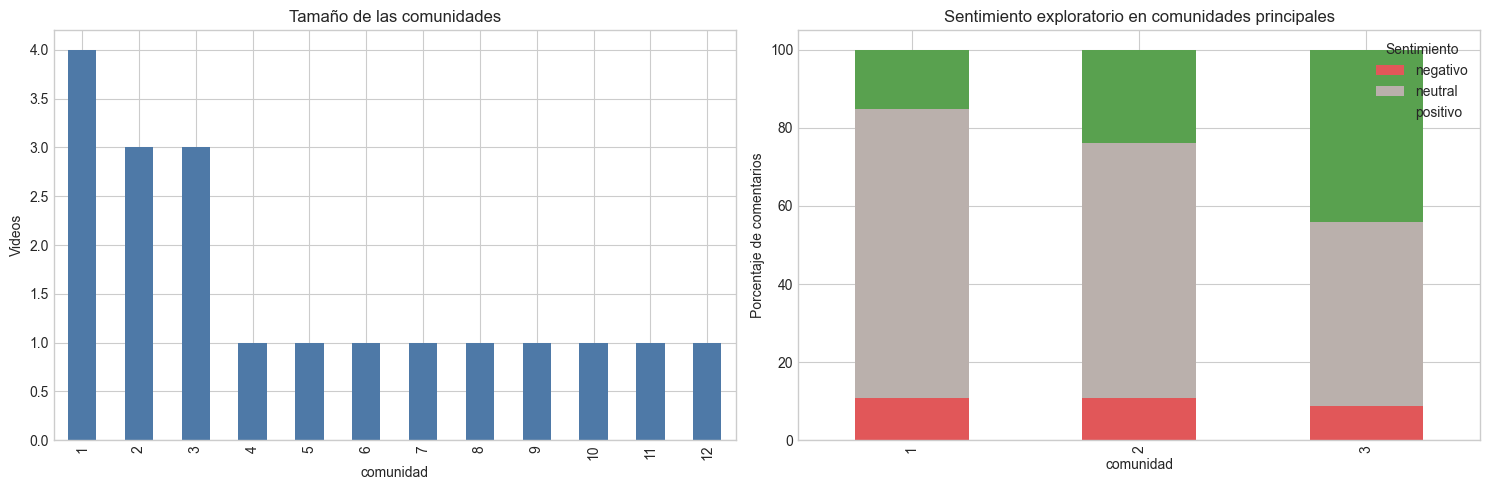

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
resumen_comunidades.plot.bar(x='comunidad', y='videos', legend=False, color='#4E79A7', ax=axes[0])
axes[0].set_title('Tamaño de las comunidades')
axes[0].set_ylabel('Videos')

sent_com = (comments[comments['comunidad'].isin(principales)]
            .groupby(['comunidad', 'sentimiento']).size().unstack(fill_value=0))
sent_com = sent_com.div(sent_com.sum(axis=1), axis=0) * 100
sent_com.reindex(columns=['negativo', 'neutral', 'positivo'], fill_value=0).plot.bar(
    stacked=True, color=['#E15759', '#BAB0AC', '#59A14F'], ax=axes[1]
)
axes[1].set_title('Sentimiento exploratorio en comunidades principales')
axes[1].set_ylabel('Porcentaje de comentarios')
axes[1].legend(title='Sentimiento')
plt.tight_layout()
plt.show()

In [19]:
for numero in principales:
    fila = resumen_comunidades.set_index('comunidad').loc[numero]
    dominante = max(
        [('positivo', fila['porcentaje_positivo']), ('neutral', fila['porcentaje_neutral']), ('negativo', fila['porcentaje_negativo'])],
        key=lambda x: x[1]
    )
    print(
        f"Comunidad {numero}: reúne {int(fila['videos'])} videos de {int(fila['canales'])} canales, "
        f"{int(fila['autores_unicos'])} autores y {int(fila['comentarios'])} comentarios. "
        f"La categoría de sentimiento más frecuente es {dominante[0]} ({dominante[1]:.1f}%). "
        f"Sus términos más frecuentes son: {fila['terminos_frecuentes']}."
    )

Comunidad 1: reúne 4 videos de 3 canales, 187 autores y 225 comentarios. La categoría de sentimiento más frecuente es neutral (74.2%). Sus términos más frecuentes son: pueblo (54), dinero (28), diputados (28), trabajo (24), diputado (22), corruptos (21), ellos (20), pais (19), sueldo (17), estan (12).
Comunidad 2: reúne 3 videos de 2 canales, 62 autores y 84 comentarios. La categoría de sentimiento más frecuente es neutral (65.5%). Sus términos más frecuentes son: presidente (27), pais (19), anos (12), arevalo (12), bernardo (9), salvador (7), estan (6), puente (6), gobierno (6), proyecto (6).
Comunidad 3: reúne 3 videos de 1 canales, 29 autores y 34 comentarios. La categoría de sentimiento más frecuente es neutral (47.1%). Sus términos más frecuentes son: excelente (10), empresas (8), internet (7), ley (7), pais (6), informacion (5), competencia (4), libre (4), mercado (4), problema (4).


### Discusión de comunidades

Las comunidades detectadas son agrupaciones estructurales de videos enlazados por autores comunes. Los términos y canales ayudan a evaluar si esa estructura también posee coherencia temática, pero no forman parte del algoritmo. Un autor puede participar en videos de varias comunidades; esto es esperable y representa circulación entre grupos, aunque la asignación de Louvain coloque cada video en una sola comunidad.

La modularidad cuantifica cuánto peso queda dentro de las comunidades frente a lo esperado por la estructura de grados. No demuestra que existan grupos sociales estables ni permite inferir ideología. Las comunidades pequeñas o unitarias pueden deberse a contenidos con audiencias no compartidas en la muestra. El sentimiento basado en léxico se interpreta como señal descriptiva: una alta proporción neutral puede significar lenguaje sin términos del diccionario, no necesariamente ausencia de opinión.

La partición produjo 12 comunidades y una modularidad ponderada de 0.4053. Nueve videos aislados generan comunidades unitarias, por lo que el análisis sustantivo se concentra en los tres grupos con varios videos. La comunidad 1 reúne 225 comentarios en cuatro videos y está dominada por contenidos de Quorum; su vocabulario sobre pueblo, dinero, diputados, sueldos y corrupción sugiere discusión crítica sobre política y recursos públicos. La comunidad 2 agrupa 84 comentarios alrededor del gobierno, la presidencia y el Puente Belice II, junto con un video noticioso de seguridad; los términos presidente, Arévalo, puente, gobierno y proyecto reflejan ese eje institucional. La comunidad 3 contiene tres videos de Quorum y 34 comentarios, con un eje sobre empresas, internet, ley, competencia y mercado.

El sentimiento neutral es la categoría más frecuente en las comunidades 1 y 2 (74.2 % y 65.5 %). En la comunidad 3, la proporción positiva llega a 44.1 % y queda cerca de la neutral (47.1 %), impulsada en parte por expresiones como ‘excelente’. Estas diferencias describen el vocabulario detectado; no bastan para afirmar una actitud colectiva sin revisar el contexto, la ironía y los comentarios no cubiertos por el léxico.

## Conclusiones de la sección 7 (proyecciones, topología y comunidades)

Las dos proyecciones responden preguntas diferentes: la autor–autor muestra coincidencia de participación y la video–video revela circulación de audiencias. Su comparación con la red bipartita permite separar actividad directa de relaciones inducidas por vecinos compartidos.

La estructura debe interpretarse mediante varias métricas a la vez. Una componente grande indica alcance estructural dentro de la muestra, mientras que densidad, distribución de grados, cohesión y transitividad muestran si ese alcance está repartido o concentrado. Los nodos periféricos describen participación poco conectada bajo la cobertura disponible, no aislamiento social real.

Louvain resume la proyección de videos en grupos con audiencia compartida y la modularidad evalúa la separación lograda. La caracterización por canales, autores, intensidad, vocabulario y sentimiento aporta contexto, pero las conclusiones siguen limitadas por la selección de contenidos y por la cobertura parcial de comentarios. Los resultados describen asociaciones observadas y no relaciones causales ni patrones generalizables a toda la plataforma.